# Plotting Reconstructed Coastlines

Plotting reconstructed coastlines shows how continents and landmasses looked in the geological past by accounting for tectonic plate movements. It involves shifting present-day coastlines back in time using a plate motion model!

### Setup

Let's begin by importing the required packages:

In [2]:
# Ensure you have the required packages installed:
# Run `pip install gplately matplotlib` if not already installed.

import gplately
import matplotlib.pyplot as plt
from plate_model_manager import PlateModelManager

Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

In [2]:
# Create a Plate Model Manager
pm_manager = PlateModelManager()

# Load & download model data into the path specified by 'data_dir'
# To load a specific model, you can specify the model name
try:
    muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")
except Exception as e:
    print(f"Error loading model: {e}")

# Fetch components of the loaded model
rotation_model_2019 = muller2019_model.get_rotation_model()
topology_features_2019 = muller2019_model.get_topologies()
static_polygons_2019 = muller2019_model.get_static_polygons()

model = gplately.PlateReconstruction(rotation_model_2019, topology_features_2019, static_polygons_2019)

### Plotting Coastlines

This code segment reconstructs and plots the ancient coastlines at a given time in the past (here, 150 Ma), using the plate motion model 'model' that we've created.

- First, we load coastlines from the model.

- Next, we move them back in time based on how tectonic plates have shifted.

- Lastly, we draw them on a world map using matplotlib (as black solid lines).

This is useful for visualizing what Earth’s surface looked like millions of years ago!

> `NOTE:` If you've loaded your plate model via local files, you can load the 'coastline_features' by reading a shapefile and converting it into a FeatureCollection object. Eg. `coastline_features = pygplates.FeatureCollection(path-to-coastline-file)`

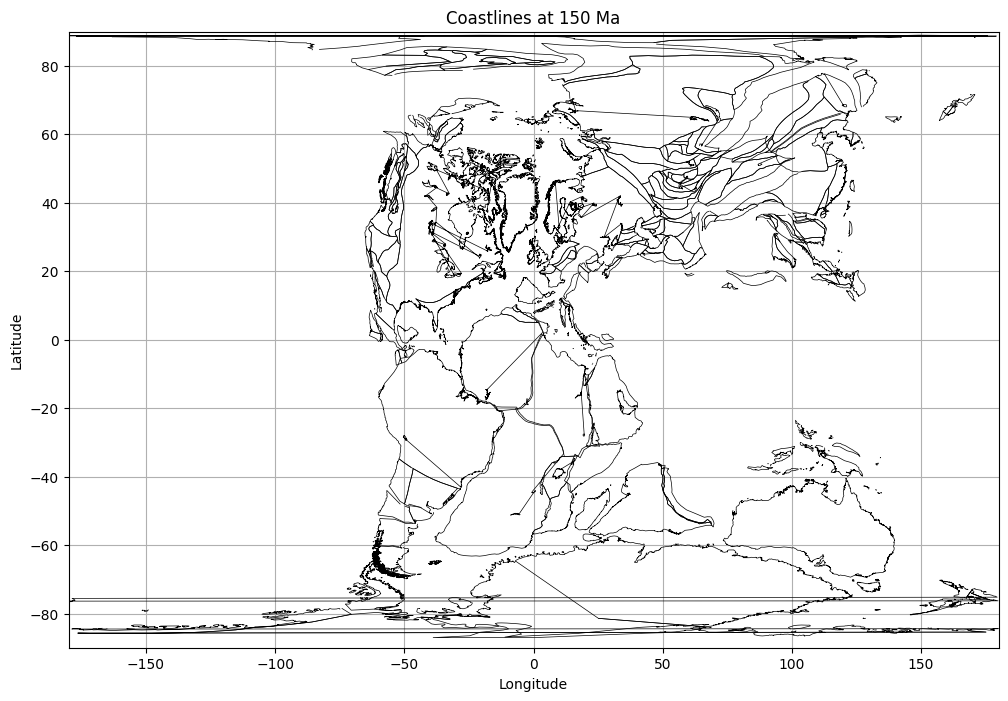

In [3]:
time = 150 # Ma

# Get present-day coastline features from the model
coastline_features = muller2019_model.get_layer('Coastlines')

# Reconstruct those coastlines to a past geological time (in Ma = million years ago)
reconstructed_coastlines = model.reconstruct(
    coastline_features,
    to_time=time
)

# Set up a plot
fig, ax = plt.subplots(figsize=(12, 8))

# Loop through each reconstructed coastline and plot it
for reconstructed_coastline in reconstructed_coastlines:
    geometry = reconstructed_coastline.get_reconstructed_geometry()
    if geometry:
        coords = geometry.to_lat_lon_array()
        lons = coords[:, 1]  # Longitude
        lats = coords[:, 0]  # Latitude
        ax.plot(lons, lats, 'k-', linewidth=0.5)  # k = black, - = solid line

# Set plot limits, labels & title
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Coastlines at {time} Ma')
ax.grid(True)

plt.show()